# 07 · Partial differential equations in one space dimension

Axes: axis 0 is time, axis 1 is space. Each section shows the data, the signal check
and one search on clean data. For the selected equation, its left-hand side
computed from the data is placed next to the value predicted by its right-hand
side, as two space–time maps and their difference.

Displayed outputs are saved examples from earlier executions and do not verify the current version. Re-execute the relevant cells to obtain current results. Searches may reuse a compatible saved run; the printed status identifies this. Recovered laws are established by the reported term comparison, rather than by the presence of a plotted equation.

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
from epde_bench.nbcache import cached_run, print_run
from epde_bench.reconstruction import plot_reconstruction
%matplotlib inline
print('EPDE imported; notebook environment ready')

EPDE imported; notebook environment ready


## Viscous Burgers equation

$$u_t = -u u_x + 0.1\,u_{xx}$$

Data of the original sparse-regression study, periodic in space.

burgers: Viscous Burgers equation (PDE-FIND data)
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (101, 256); variables: u
  t: [0, 10], 101 points
  x: [-8, 7.938], 256 points
  truth:
    -1.0 * u{power: 1.0} * du/dx1{power: 1.0} + 0.1 * d^2u/dx1^2{power: 1.0} = du/dx0{power: 1.0}
  notes: u_t = -u u_x + 0.1 u_xx, periodic in x.


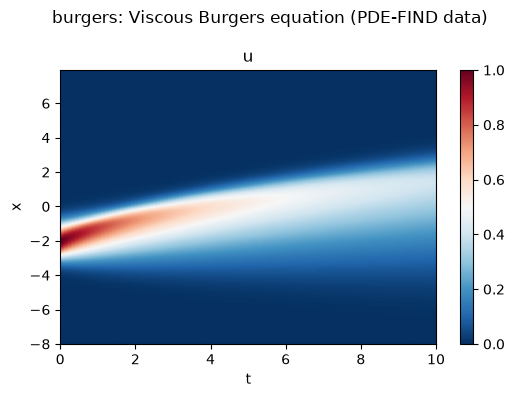

In [2]:
p = datasets.load('burgers')
print(p.summary())
plot_problem(p); plt.show()

In [3]:
p, report = check('burgers', noise_levels=[0, 1, 5])
print_check(p, report)

burgers: Viscous Burgers equation (PDE-FIND data)
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (101, 256); variables: u
  t: [0, 10], 101 points
  x: [-8, 7.938], 256 points
  truth:
    -1.0 * u{power: 1.0} * du/dx1{power: 1.0} + 0.1 * d^2u/dx1^2{power: 1.0} = du/dx0{power: 1.0}
  notes: u_t = -u u_x + 0.1 u_xx, periodic in x.



=== noise 0 % ===
R^2 of the true structure: 0.999964   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx1{'power': 1.0} * u{'power': 1.0}                             -1      -1.0008            9.584e-01
  d^2u/dx1^2{'power': 1.0}                                          0.1       0.1013            2.224e-01

=== noise 1 % ===
R^2 of the true structure: 0.844867   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx1{'power': 1.0} * u{'power': 1.0}                             -1      -0.9265            8.242e-01
  d^2u/dx1^2{'power': 1.0}                                          0.1     0.050392            1.055e-01

=== noise 5 % ===
R^2 of the true structure: 0.319490   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx1{'power': 1.0} 

In [4]:
rec = cached_run('burgers', variant='default', noise=0.0, seed=0)
print_run(rec)

ok fit 131 s (from cache)
[0] <- compromise pick
     -0.00011327905523714721 * d^4u/dx1^4{power: 1.0} + 0.10015608220094888 * d^2u/dx1^2{power: 1.0} + -1.001569311587228 * u{power: 1.0} * du/dx1{power: 1.0} + 0.0 = du/dx0{power: 1.0}
[1]
     0.10130397554837355 * d^2u/dx1^2{power: 1.0} + -1.0007844013113738 * u{power: 1.0} * du/dx1{power: 1.0} + 0.0 = du/dx0{power: 1.0}
{'front_size': 2, 'selected_index': 0, 'success_front': True, 'success_selected': False, 'hamming_min': 0, 'hamming_selected': 1, 'coef_error': 0.006912078397554602}


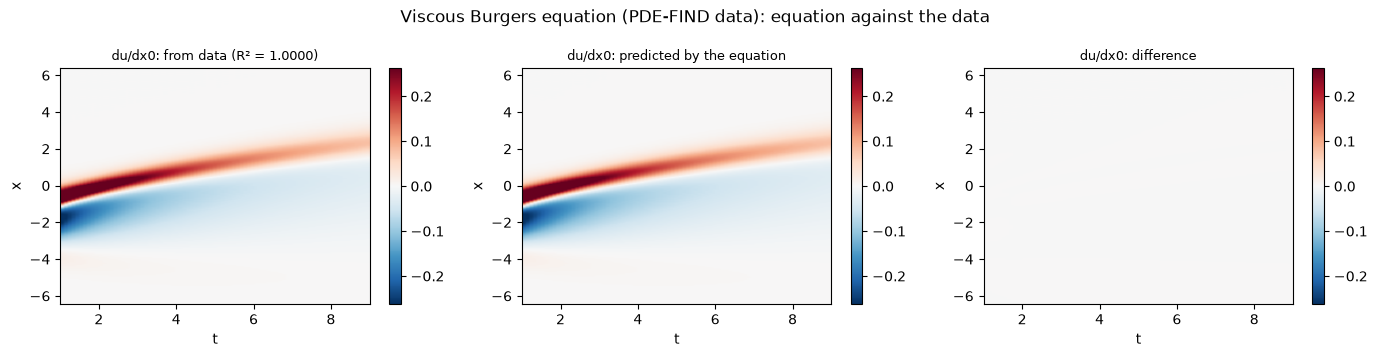

{'du/dx0{power: 1.0}': 1.0}


In [5]:
problem = datasets.load('burgers')
search_cfg = resolve_for_problem(load_config('burgers'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

## Inviscid Burgers equation

$$u_t = -u u_x$$

The record is the similarity solution $u = x/(t + c)$, so two identities hold besides the equation itself; they count as correct.

burgers_inviscid: Inviscid Burgers equation
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (101, 101); variables: u
  t: [0, 1], 101 points
  x: [-1000, 0], 101 points
  truth:
    -1.0 * u{power: 1.0} * du/dx1{power: 1.0} = du/dx0{power: 1.0}
  + 2 equivalent form(s)
  notes: The record is the similarity solution u = x / (t + c), so two identities hold as well as the PDE and count as correct.


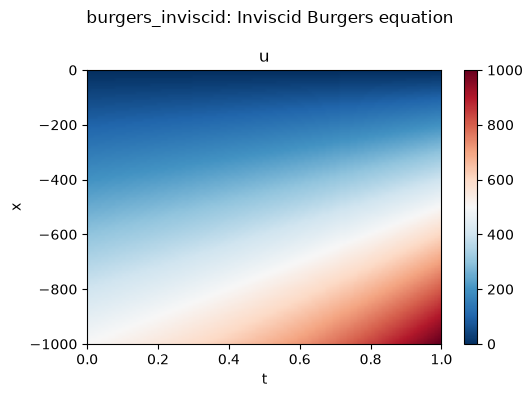

In [6]:
p = datasets.load('burgers_inviscid')
print(p.summary())
plot_problem(p); plt.show()

In [7]:
p, report = check('burgers_inviscid', noise_levels=[0, 1, 5])
print_check(p, report)

burgers_inviscid: Inviscid Burgers equation
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (101, 101); variables: u
  t: [0, 1], 101 points
  x: [-1000, 0], 101 points
  truth:
    -1.0 * u{power: 1.0} * du/dx1{power: 1.0} = du/dx0{power: 1.0}
  + 2 equivalent form(s)
  notes: The record is the similarity solution u = x / (t + c), so two identities hold as well as the PDE and count as correct.

=== noise 0 % ===
R^2 of the true structure: 1.000000   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx1{'power': 1.0} * u{'power': 1.0}                             -1      -1.0001            1.000e+00

=== noise 1 % ===
R^2 of the true structure: 0.376900   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx1{'power': 1.0} * u{'power': 1.0}                             -1     -0.84553            3.7

In [8]:
rec = cached_run('burgers_inviscid', variant='default', noise=0.0, seed=0)
print_run(rec)

ok fit 198 s (from cache)
[0] <- compromise pick
     0.9999999999999998 * u{power: 1.0} + 0.0 = x{power: 1.0, dim: 1.0} * du/dx1{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'coef_error': 2.220446049250313e-16}


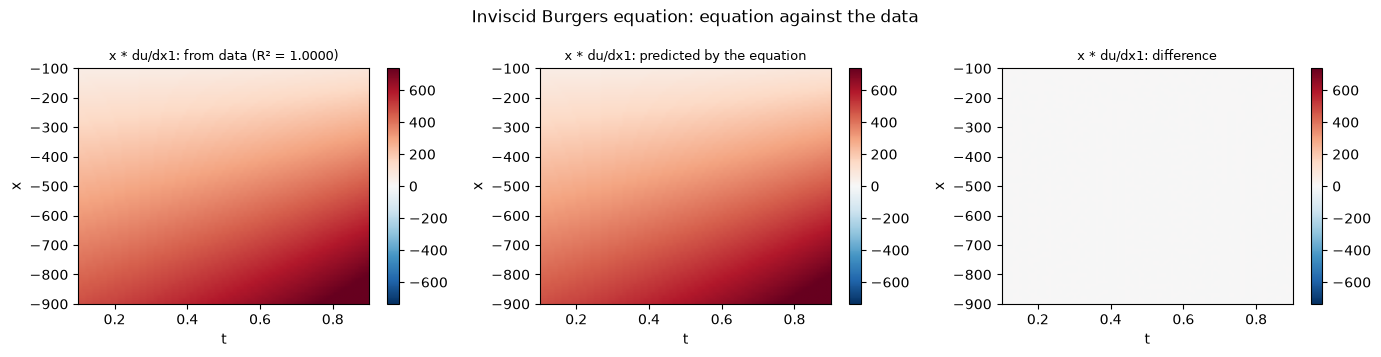

{'x{power: 1.0, dim: 1.0} * du/dx1{power: 1.0}': 1.0}


In [9]:
problem = datasets.load('burgers_inviscid')
search_cfg = resolve_for_problem(load_config('burgers_inviscid'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

## Wave equation

$$u_{tt} = 0.04\,u_{xx}$$

The wave equation multiplied by another factor also counts as correct.

wave: Wave equation
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (81, 81); variables: u
  t: [0, 1], 81 points
  x: [0, 1], 81 points
  truth:
    0.04 * d^2u/dx1^2{power: 1.0} = d^2u/dx0^2{power: 1.0}
  + 4 equivalent form(s)
  notes: u_tt = 0.04 u_xx. The alternatives are the wave equation multiplied by another factor; they are accepted as in the group's former benchmark.


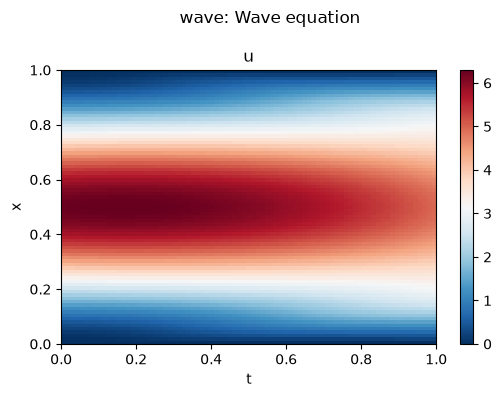

In [10]:
p = datasets.load('wave')
print(p.summary())
plot_problem(p); plt.show()

In [11]:
p, report = check('wave', noise_levels=[0, 1, 5])
print_check(p, report)

wave: Wave equation
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (81, 81); variables: u
  t: [0, 1], 81 points
  x: [0, 1], 81 points
  truth:
    0.04 * d^2u/dx1^2{power: 1.0} = d^2u/dx0^2{power: 1.0}
  + 4 equivalent form(s)
  notes: u_tt = 0.04 u_xx. The alternatives are the wave equation multiplied by another factor; they are accepted as in the group's former benchmark.

=== noise 0 % ===
R^2 of the true structure: 0.999540   (d^2u/dx0^2{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  d^2u/dx1^2{'power': 1.0}                                         0.04     0.040383            9.995e-01

=== noise 1 % ===
R^2 of the true structure: 0.309107   (d^2u/dx0^2{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  d^2u/dx1^2{'power': 1.0}                                         0.04      0.46434            3.091e-01

==

In [12]:
rec = cached_run('wave', variant='default', noise=0.0, seed=0)
print_run(rec)

ok

 fit 157 s (from cache)
[0] <- compromise pick
     0.040271039395618685 * d^2u/dx1^2{power: 1.0} + 0.0 = d^2u/dx0^2{power: 1.0}
[1]
     1.1136557834461986e-05 * u{power: 3.0} * d^2u/dx1^2{power: 1.0} + 0.041142957997540856 * d^2u/dx1^2{power: 1.0} + -9.725642573257377e-05 * d^2u/dx1^2{power: 1.0} * u{power: 2.0} + 0.0 = d^2u/dx0^2{power: 1.0}
{'front_size': 2, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'coef_error': 0.0067759848904671086}


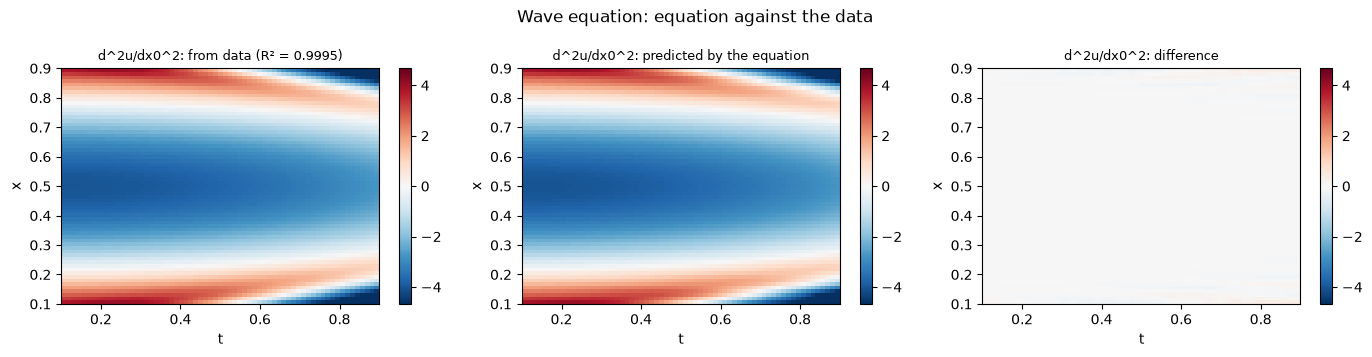

{'d^2u/dx0^2{power: 1.0}': 0.9995}


In [13]:
problem = datasets.load('wave')
search_cfg = resolve_for_problem(load_config('wave'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

## Allen–Cahn equation

$$u_t = 10^{-4} u_{xx} + 5u - 5u^3$$

The diffusion term is tiny, which makes it hard to separate from noise.

ac: Allen-Cahn equation
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (51, 128); variables: u
  t: [0, 1], 51 points
  x: [-1, 0.9844], 128 points
  truth:
    0.0001 * d^2u/dx1^2{power: 1.0} + -5.0 * u{power: 3.0} + 5.0 * u{power: 1.0} = du/dx0{power: 1.0}
  notes: u_t = 1e-4 u_xx + 5u - 5u^3. The diffusion term is tiny, which makes it hard to separate from noise.


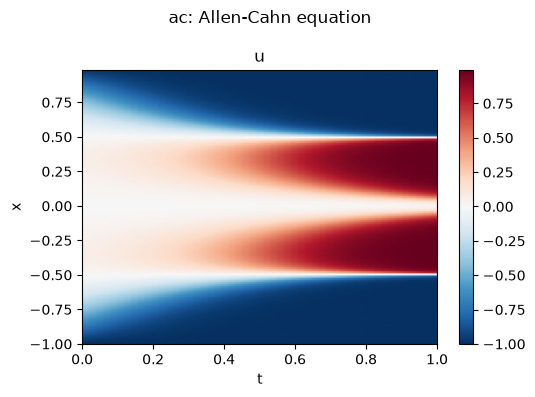

In [14]:
p = datasets.load('ac')
print(p.summary())
plot_problem(p); plt.show()

In [15]:
p, report = check('ac', noise_levels=[0, 1, 5])
print_check(p, report)

ac: Allen-Cahn equation
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (51, 128); variables: u
  t: [0, 1], 51 points
  x: [-1, 0.9844], 128 points
  truth:
    0.0001 * d^2u/dx1^2{power: 1.0} + -5.0 * u{power: 3.0} + 5.0 * u{power: 1.0} = du/dx0{power: 1.0}
  notes: u_t = 1e-4 u_xx + 5u - 5u^3. The diffusion term is tiny, which makes it hard to separate from noise.

=== noise 0 % ===
R^2 of the true structure: 0.999962   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  d^2u/dx1^2{'power': 1.0}                                       0.0001   0.00013592            2.034e-04
  u{'power': 3.0}                                                    -5      -4.9911            4.619e-01
  u{'power': 1.0}                                                     5       4.9946            6.916e-01

=== noise 1 % ===
R^2 of the true structure: 0.949060   (du/dx0{power: 1.0})
  term               

In [16]:
rec = cached_run('ac', variant='default', noise=0.0, seed=0)
print_run(rec)

ok fit 94 s (from cache)
[0]
     -4.992722202877452 * u{power: 3.0} + 4.995789638780083 * u{power: 1.0} + 0.00013629842586855153 * d^2u/dx1^2{power: 1.0} + 0.0 = du/dx0{power: 1.0}
[1]
     -4.9682668448313985 * u{power: 3.0} + 4.968611741148819 * u{power: 1.0} + 0.0 = du/dx0{power: 1.0}
[2] <- compromise pick
     -4.9879106273143226 * u{power: 3.0} + 4.9909936600271765 * u{power: 1.0} + 0.00016460848763719764 * x{power: 1.0, dim: 0.0} * d^2u/dx1^2{power: 1.0} + 0.0 = du/dx0{power: 1.0}
{'front_size': 3, 'selected_index': 2, 'success_front': True, 'success_selected': False, 'hamming_min': 0, 'hamming_selected': 2, 'coef_error': 0.1217606301180027}


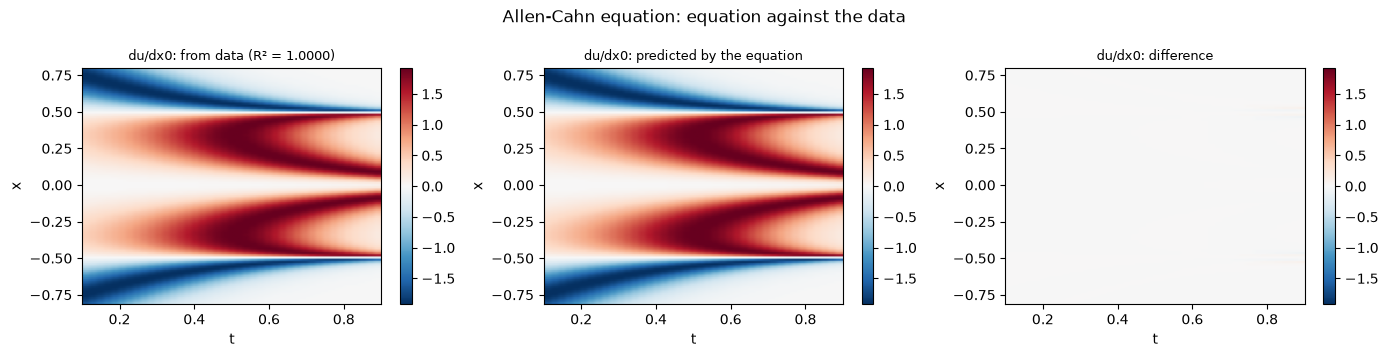

{'du/dx0{power: 1.0}': 1.0}


In [17]:
problem = datasets.load('ac')
search_cfg = resolve_for_problem(load_config('ac'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

## Korteweg–de Vries equation

$$u_t = -6 u u_x - u_{xxx}$$

The record is a soliton family, so three identities of it are also exact and accepted.

kdv: Korteweg-de Vries equation (PDE-FIND data)
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (201, 512); variables: u
  t: [0, 20], 201 points
  x: [-30, 29.88], 512 points
  truth:
    -6.0 * du/dx1{power: 1.0} * u{power: 1.0} + -1.0 * d^3u/dx1^3{power: 1.0} = du/dx0{power: 1.0}
  + 3 equivalent form(s)
  notes: u_t = -6 u u_x - u_xxx. The record is a soliton family, so three identities of it are also exact and accepted.


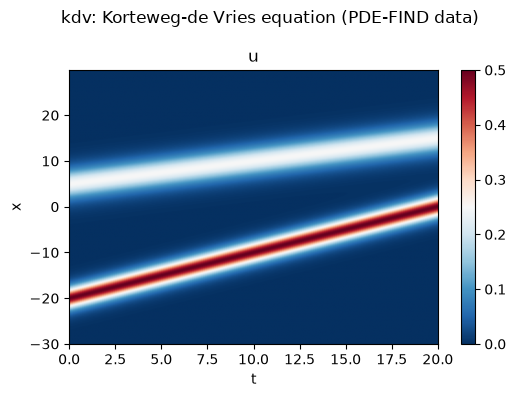

In [18]:
p = datasets.load('kdv')
print(p.summary())
plot_problem(p); plt.show()

In [19]:
p, report = check('kdv', noise_levels=[0, 1, 5])
print_check(p, report)

kdv: Korteweg-de Vries equation (PDE-FIND data)
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (201, 512); variables: u
  t: [0, 20], 201 points
  x: [-30, 29.88], 512 points
  truth:
    -6.0 * du/dx1{power: 1.0} * u{power: 1.0} + -1.0 * d^3u/dx1^3{power: 1.0} = du/dx0{power: 1.0}
  + 3 equivalent form(s)
  notes: u_t = -6 u u_x - u_xxx. The record is a soliton family, so three identities of it are also exact and accepted.

=== noise 0 % ===
R^2 of the true structure: 0.999577   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx1{'power': 1.0} * u{'power': 1.0}                             -6      -6.0441            4.847e-01
  d^3u/dx1^3{'power': 1.0}                                           -1       -1.024            1.425e-01

=== noise 1 % ===
R^2 of the true structure: 0.839201   (du/dx0{power: 1.0})
  term                                                             t

In [20]:
rec = cached_run('kdv', variant='default', noise=0.0, seed=0)
print_run(rec)

ok fit 488 s (from cache)
[0] <- compromise pick
     -1.50092542808946 * du/dx0{power: 1.0} * du/dx1{power: 1.0} + -0.5006666207657561 * du/dx1{power: 2.0} + 0.0 = du/dx0{power: 2.0}
{'front_size': 1, 'selected_index': 0, 'success_front': False, 'success_selected': False, 'hamming_min': 4, 'hamming_selected': 4, 'coef_error': None}


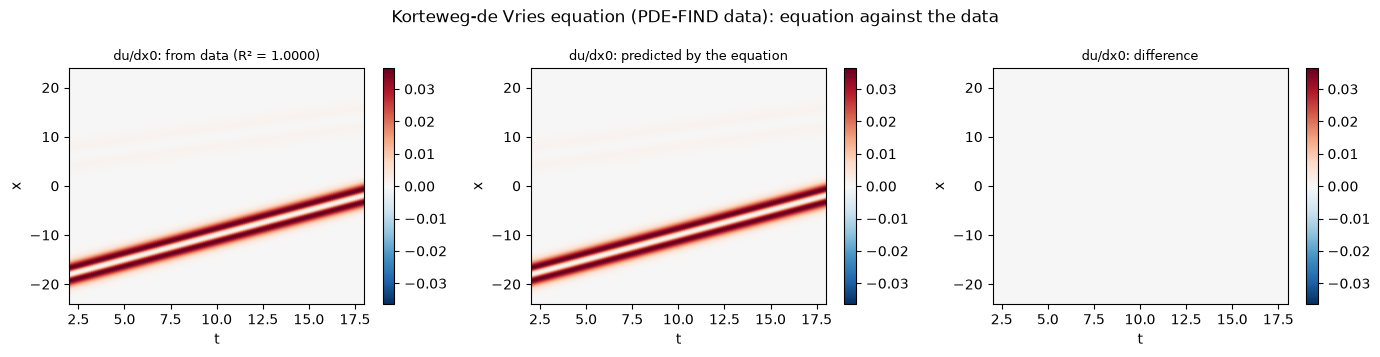

{'du/dx0{power: 2.0}': 1.0}


In [21]:
problem = datasets.load('kdv')
search_cfg = resolve_for_problem(load_config('kdv'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

## Korteweg–de Vries equation with a source

$$u_t = -6 u u_x - u_{xxx} + \cos t \sin x$$

The source enters as one product token.

kdv_cossin: KdV with a cos(t)sin(x) source
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (81, 81); variables: u
  t: [0, 1], 81 points
  x: [0, 1], 81 points
  truth:
    -6.0 * du/dx1{power: 1.0} * u{power: 1.0} + -1.0 * d^3u/dx1^3{power: 1.0} + 1.0 * cos(t)sin(x){power: 1.0} = du/dx0{power: 1.0}
  notes: The source enters as one product token cos(t)sin(x).


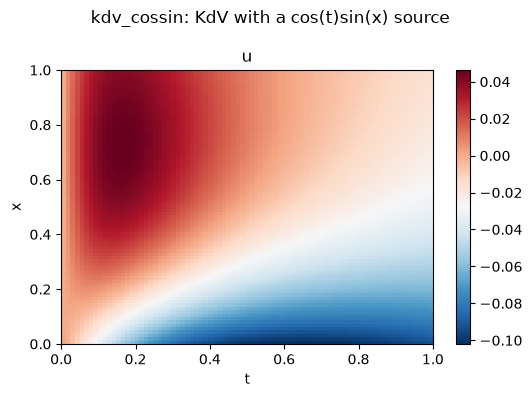

In [22]:
p = datasets.load('kdv_cossin')
print(p.summary())
plot_problem(p); plt.show()

In [23]:
p, report = check('kdv_cossin', noise_levels=[0, 1, 5])
print_check(p, report)

kdv_cossin: KdV with a cos(t)sin(x) source
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (81, 81); variables: u
  t: [0, 1], 81 points
  x: [0, 1], 81 points
  truth:
    -6.0 * du/dx1{power: 1.0} * u{power: 1.0} + -1.0 * d^3u/dx1^3{power: 1.0} + 1.0 * cos(t)sin(x){power: 1.0} = du/dx0{power: 1.0}
  notes: The source enters as one product token cos(t)sin(x).

=== noise 0 % ===
R^2 of the true structure: 0.999979   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx1{'power': 1.0} * u{'power': 1.0}                             -6      -5.9884            1.170e-01
  d^3u/dx1^3{'power': 1.0}                                           -1      -1.0015            9.334e-01
  cos(t)sin(x){'power': 1.0}                                          1        1.001            9.259e-01

=== noise 1 % ===
R^2 of the true structure: 0.054630   (du/dx0{power: 1.0})
  term                      

In [24]:
rec = cached_run('kdv_cossin', variant='default', noise=0.0, seed=0)
print_run(rec)

ok

 fit 258 s (from cache)
[0] <- compromise pick
     -0.9994207971051062 * du/dx0{power: 1.0} + 1.0001906225041306 * cos(t)sin(x){power: 1.0} + -6.005119782804773 * u{power: 1.0} * du/dx1{power: 1.0} + 0.0 = d^3u/dx1^3{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'coef_error': 0.0009277134419581025}


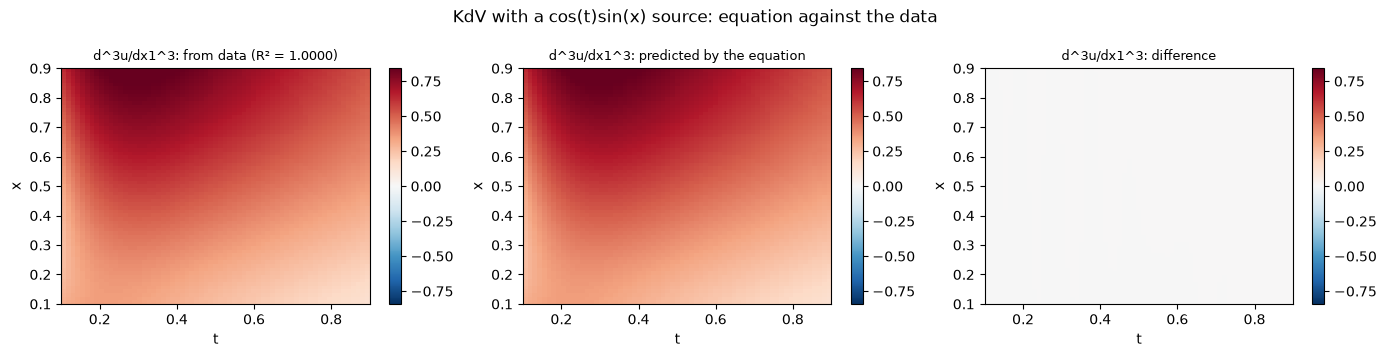

{'d^3u/dx1^3{power: 1.0}': 1.0}


In [25]:
problem = datasets.load('kdv_cossin')
search_cfg = resolve_for_problem(load_config('kdv_cossin'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

## Korteweg–de Vries equation on a short interval

$$u_t = -6 u u_x - u_{xxx}, \qquad x \in [-3, 3]$$

kdv_homogen: KdV, homogeneous, x in [-3, 3]
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (120, 480); variables: u
  t: [0, 1], 120 points
  x: [-3, 3], 480 points
  truth:
    -6.0 * du/dx1{power: 1.0} * u{power: 1.0} + -1.0 * d^3u/dx1^3{power: 1.0} = du/dx0{power: 1.0}
  notes: Same law on a short interval, as in the group's original experiments.


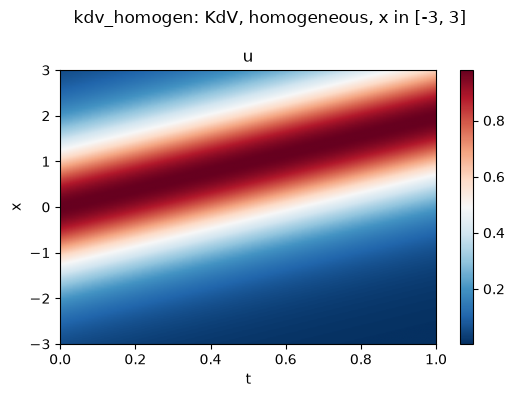

In [26]:
p = datasets.load('kdv_homogen')
print(p.summary())
plot_problem(p); plt.show()

In [27]:
p, report = check('kdv_homogen', noise_levels=[0, 1, 5])
print_check(p, report)

kdv_homogen: KdV, homogeneous, x in [-3, 3]
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (120, 480); variables: u
  t: [0, 1], 120 points
  x: [-3, 3], 480 points
  truth:
    -6.0 * du/dx1{power: 1.0} * u{power: 1.0} + -1.0 * d^3u/dx1^3{power: 1.0} = du/dx0{power: 1.0}
  notes: Same law on a short interval, as in the group's original experiments.

=== noise 0 % ===
R^2 of the true structure: 1.000000   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx1{'power': 1.0} * u{'power': 1.0}                             -6      -6.0017            3.317e-01
  d^3u/dx1^3{'power': 1.0}                                           -1      -1.0008            1.003e-01

=== noise 1 % ===
R^2 of the true structure: 0.696039   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx1{'power': 1.0} * u{'power': 1.

This section does not run a discovery. The data and checks shown here do not establish that an equation was recovered. A full search can be launched from the command line or the app; no run time or success is claimed here.

## Korteweg–de Vries equation, record of the symbolic genetic algorithm study

$$u_t = -u u_x - 0.0025\,u_{xxx}$$

kdv_sga: KdV, SGA-PDE record (u_t = -u u_x - 0.0025 u_xxx)
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (201, 512); variables: u
  t: [0, 1], 201 points
  x: [-1, 0.9961], 512 points
  truth:
    -1.0 * du/dx1{power: 1.0} * u{power: 1.0} + -0.0025 * d^3u/dx1^3{power: 1.0} = du/dx0{power: 1.0}
  notes: The record used in the symbolic genetic algorithm study.


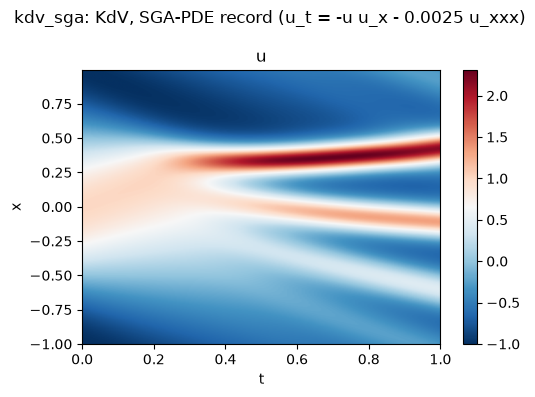

In [28]:
p = datasets.load('kdv_sga')
print(p.summary())
plot_problem(p); plt.show()

In [29]:
p, report = check('kdv_sga', noise_levels=[0, 1, 5])
print_check(p, report)

kdv_sga: KdV, SGA-PDE record (u_t = -u u_x - 0.0025 u_xxx)
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (201, 512); variables: u
  t: [0, 1], 201 points
  x: [-1, 0.9961], 512 points
  truth:
    -1.0 * du/dx1{power: 1.0} * u{power: 1.0} + -0.0025 * d^3u/dx1^3{power: 1.0} = du/dx0{power: 1.0}
  notes: The record used in the symbolic genetic algorithm study.

=== noise 0 % ===
R^2 of the true structure: 0.999694   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx1{'power': 1.0} * u{'power': 1.0}                             -1      -1.0003            9.911e-01
  d^3u/dx1^3{'power': 1.0}                                      -0.0025   -0.0025136            8.933e-01

=== noise 1 % ===
R^2 of the true structure: 0.081378   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx1{'power': 1.0} * u{'

This section does not run a discovery. The data and checks shown here do not establish that an equation was recovered. A full search can be launched from the command line or the app; no run time or success is claimed here.

## Nonlinear diffusion

$$u_t = (u u_x)_x = u_x^2 + u u_{xx}$$

pde_compound: Nonlinear diffusion u_t = (u u_x)_x
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (251, 100); variables: u
  t: [0, 0.5], 251 points
  x: [1, 2], 100 points
  truth:
    1.0 * du/dx1{power: 2.0} + 1.0 * d^2u/dx1^2{power: 1.0} * u{power: 1.0} = du/dx0{power: 1.0}
  notes: u_t = u_x^2 + u u_xx on t in [0, 0.5], x in [1, 2].


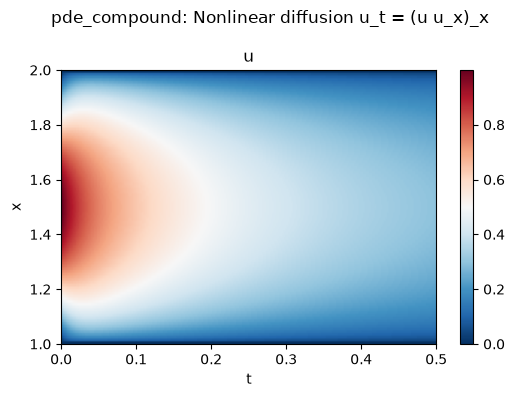

In [30]:
p = datasets.load('pde_compound')
print(p.summary())
plot_problem(p); plt.show()

In [31]:
p, report = check('pde_compound', noise_levels=[0, 1, 5])
print_check(p, report)

pde_compound: Nonlinear diffusion u_t = (u u_x)_x
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (251, 100); variables: u
  t: [0, 0.5], 251 points
  x: [1, 2], 100 points
  truth:
    1.0 * du/dx1{power: 2.0} + 1.0 * d^2u/dx1^2{power: 1.0} * u{power: 1.0} = du/dx0{power: 1.0}
  notes: u_t = u_x^2 + u u_xx on t in [0, 0.5], x in [1, 2].

=== noise 0 % ===
R^2 of the true structure: 0.999988   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx1{'power': 2.0}                                                1        1.009            5.555e-01
  d^2u/dx1^2{'power': 1.0} * u{'power': 1.0}                          1       1.0009            9.997e-01

=== noise 1 % ===
R^2 of the true structure: 0.004883   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx1{'power': 2.0}                             

In [32]:
rec = cached_run('pde_compound', variant='default', noise=0.0, seed=0)
print_run(rec)

ok fit 317 s (from cache)
[0] <- compromise pick
     0.9990966019165756 * du/dx0{power: 1.0} + -1.0081108570607558 * du/dx1{power: 2.0} + 0.0 = u{power: 1.0} * d^2u/dx1^2{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'coef_error': 0.004963310458958481}


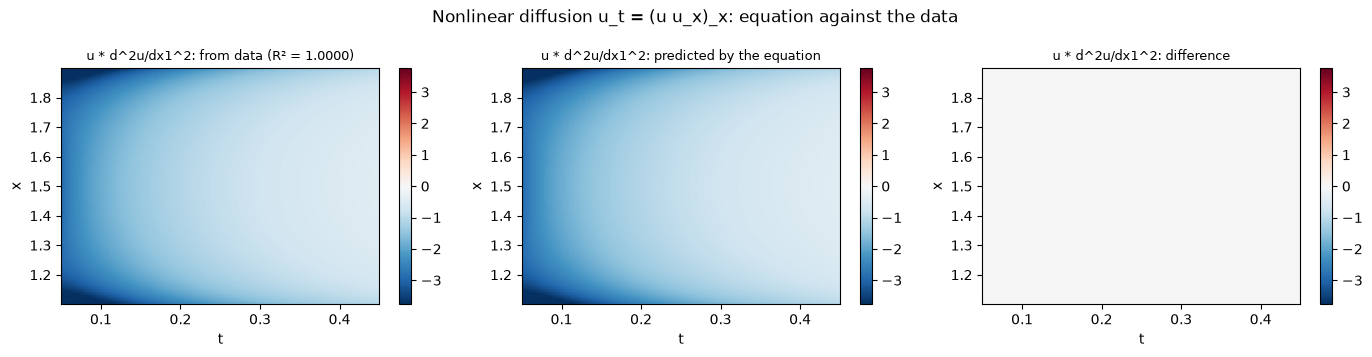

{'u{power: 1.0} * d^2u/dx1^2{power: 1.0}': 1.0}


In [33]:
problem = datasets.load('pde_compound')
search_cfg = resolve_for_problem(load_config('pde_compound'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

## Equation with a $1/x$ coefficient

$$x u_t = -2 u_x + 0.5\,x u_{xx}$$

The coordinate token is needed to express the coefficient.

pde_divide: PDE with a 1/x coefficient
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (251, 100); variables: u
  t: [0, 0.5], 251 points
  x: [1, 2], 100 points
  truth:
    -2.0 * du/dx1{power: 1.0} + 0.5 * d^2u/dx1^2{power: 1.0} * x{power: 1.0, dim: 1.0} = du/dx0{power: 1.0} * x{power: 1.0, dim: 1.0}
  notes: x u_t = -2 u_x + 0.5 x u_xx, i.e. u_t = -2 u_x / x + 0.5 u_xx (needs the x token).


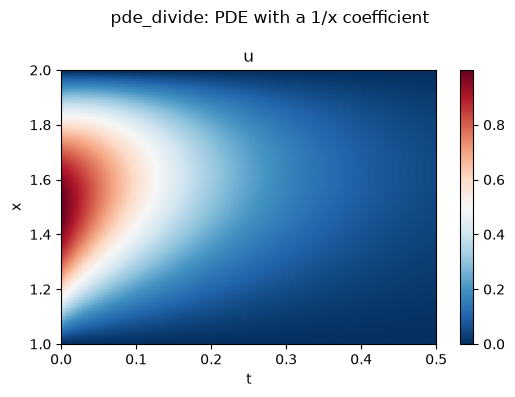

In [34]:
p = datasets.load('pde_divide')
print(p.summary())
plot_problem(p); plt.show()

In [35]:
p, report = check('pde_divide', noise_levels=[0, 1, 5])
print_check(p, report)

pde_divide: PDE with a 1/x coefficient
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (251, 100); variables: u
  t: [0, 0.5], 251 points
  x: [1, 2], 100 points
  truth:
    -2.0 * du/dx1{power: 1.0} + 0.5 * d^2u/dx1^2{power: 1.0} * x{power: 1.0, dim: 1.0} = du/dx0{power: 1.0} * x{power: 1.0, dim: 1.0}
  notes: x u_t = -2 u_x + 0.5 x u_xx, i.e. u_t = -2 u_x / x + 0.5 u_xx (needs the x token).

=== noise 0 % ===
R^2 of the true structure: 1.000000   (du/dx0{power: 1.0} * x{power: 1.0, dim: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx1{'power': 1.0}                                               -2      -2.0001            4.228e-01
  d^2u/dx1^2{'power': 1.0} * x{'dim': 1.0, 'power': 1.0}            0.5      0.50013            9.980e-01

=== noise 1 % ===
R^2 of the true structure: 0.017354   (du/dx0{power: 1.0} * x{power: 1.0, dim: 1.0})
  term                                          

In [36]:
rec = cached_run('pde_divide', variant='default', noise=0.0, seed=0)
print_run(rec)

ok fit 595 s (from cache)
[0] <- compromise pick
     0.5001158970161292 * x{power: 1.0, dim: 1.0} * d^2u/dx1^2{power: 1.0} + -1.9999773784431472 * du/dx1{power: 1.0} + 0.0 = du/dx0{power: 1.0} * x{power: 1.0, dim: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'coef_error': 0.00012155240534245104}


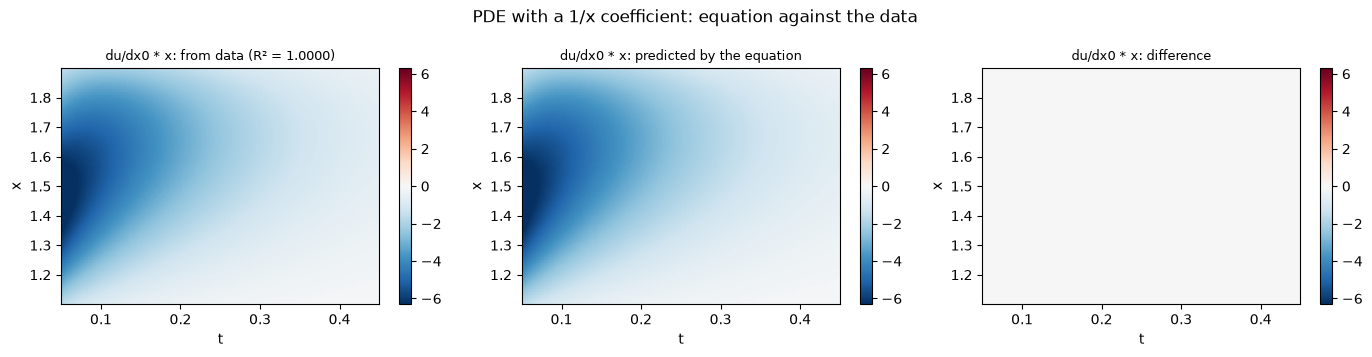

{'du/dx0{power: 1.0} * x{power: 1.0, dim: 1.0}': 1.0}


In [37]:
problem = datasets.load('pde_divide')
search_cfg = resolve_for_problem(load_config('pde_divide'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

## Kuramoto–Sivashinsky equation

$$u_t = -u u_x - u_{xx} - u_{xxxx}$$

Chaotic; needs the fourth derivative.

ks: Kuramoto-Sivashinsky equation
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (251, 1024); variables: u
  t: [0, 100], 251 points
  x: [0.09817, 100.5], 1024 points
  truth:
    -1.0 * u{power: 1.0} * du/dx1{power: 1.0} + -1.0 * d^2u/dx1^2{power: 1.0} + -1.0 * d^4u/dx1^4{power: 1.0} = du/dx0{power: 1.0}
  notes: u_t = -u u_x - u_xx - u_xxxx; chaotic, needs a 4th derivative.


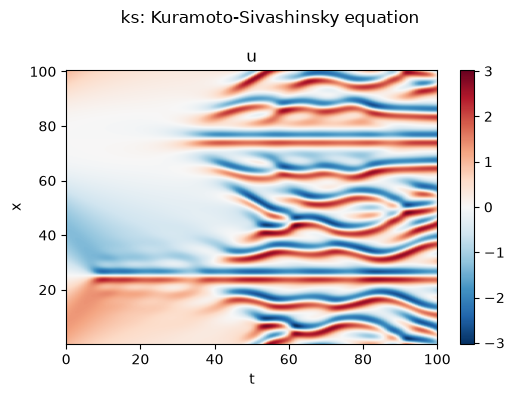

In [38]:
p = datasets.load('ks')
print(p.summary())
plot_problem(p); plt.show()

In [39]:
p, report = check('ks', noise_levels=[0, 1, 5])
print_check(p, report)

ks: Kuramoto-Sivashinsky equation
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (251, 1024); variables: u
  t: [0, 100], 251 points
  x: [0.09817, 100.5], 1024 points
  truth:
    -1.0 * u{power: 1.0} * du/dx1{power: 1.0} + -1.0 * d^2u/dx1^2{power: 1.0} + -1.0 * d^4u/dx1^4{power: 1.0} = du/dx0{power: 1.0}
  notes: u_t = -u u_x - u_xx - u_xxxx; chaotic, needs a 4th derivative.

=== noise 0 % ===
R^2 of the true structure: 0.997816   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx1{'power': 1.0} * u{'power': 1.0}                             -1     -0.99128            9.965e-01
  d^2u/dx1^2{'power': 1.0}                                           -1      -1.0109            8.384e-01
  d^4u/dx1^4{'power': 1.0}                                           -1      -1.0153            9.390e-01

=== noise 1 % ===
R^2 of the true structure: 0.057093   (du/dx0{power: 1.0})
  term    

This section does not run a discovery. The data and checks shown here do not establish that an equation was recovered. A full search can be launched from the command line or the app; no run time or success is claimed here.

## Heat in soil under solar forcing

Simulated soil temperature with a periodic surface flux. The expected law inside the soil is the heat equation $u_t = a\,u_{xx}$; the coefficient is not stored, so the run is not scored.

heat_solar_1d: Heat in soil under solar forcing, 1-D
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (576, 51); variables: u
  t: [300, 1.728e+05], 576 points
  x: [-1.5, 0], 51 points
  truth: unknown
  notes: Simulated soil temperature with a periodic surface flux. Expected law: the heat equation u_t = a u_xx in the interior (coefficient not stored), so no truth is scored. The data also hold the time derivative.


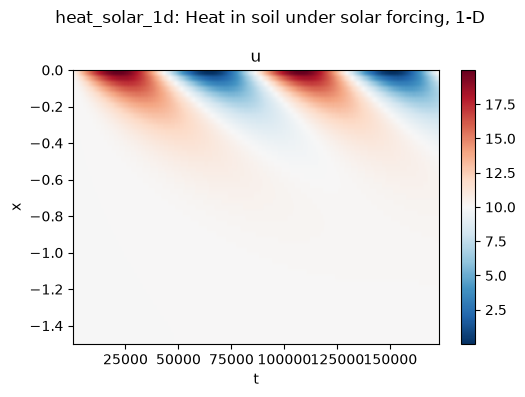

In [40]:
p = datasets.load('heat_solar_1d')
print(p.summary())
plot_problem(p); plt.show()

This section does not run a discovery. The data and checks shown here do not establish that an equation was recovered. A full search can be launched from the command line or the app; no run time or success is claimed here.